# 6CS012 – Final Portfolio Assessment 2026
## Part II: Image Classification with Convolutional Neural Networks
### Deep Learning-Based Sign Language Detection Using CNN

**Student:** Aaron Shrestha  
**Student ID:** 2408198  
**Team Members:** Suyog Acharya, Aaron Shrestha, Adarsha Ghimire, Sanjay Rijal  
**Dataset:** Sign Language Gesture Dataset  
**Classes:** 38  
**Goal:** Compare baseline CNN, deeper CNN, optimizer impact, ablation study, and transfer learning for sign language gesture classification.

---

## Notebook Roadmap

This notebook follows the 6CS012 Vision Task requirements:

1. Dataset understanding, analysis, visualization, and cleaning  
2. Preprocessing and data augmentation  
3. Baseline CNN from scratch  
4. Deeper CNN with regularization  
5. Optimizer comparison: SGD vs Adam  
6. Ablation study  
7. Transfer learning with MobileNetV2  
8. Final model comparison and viva-ready observations  

> **Important:** Run this notebook in Google Colab with GPU enabled.  
> Go to **Runtime → Change runtime type → GPU**.

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import zipfile

# ============================================================
# Correct Google Drive ZIP path
# Your file name in My Drive is:
# Sign_Language_Detection_Dataset.zip
# ============================================================
DRIVE_ZIP_PATH = "/content/drive/MyDrive/Sign_Language_Detection_Dataset.zip"

# Local Colab paths
LOCAL_ZIP_PATH = "/content/Sign_Language_Detection_Dataset.zip"
EXTRACT_DIR = "/content/sign_language_dataset"

# Check if ZIP exists in Google Drive
if not os.path.exists(DRIVE_ZIP_PATH):
    raise FileNotFoundError(
        f"ZIP file not found at: {DRIVE_ZIP_PATH}\n"
        "Please check the exact file name in Google Drive."
    )

# Copy ZIP from Google Drive to fast Colab storage
if not os.path.exists(LOCAL_ZIP_PATH):
    print("Copying ZIP from Drive to Colab local storage...")
    shutil.copy(DRIVE_ZIP_PATH, LOCAL_ZIP_PATH)
    print("ZIP copied successfully.")
else:
    print("ZIP already exists in Colab local storage.")

# Extract ZIP if not already extracted
if not os.path.exists(EXTRACT_DIR) or len(os.listdir(EXTRACT_DIR)) == 0:
    print("Extracting dataset...")
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

print("Extraction directory:", EXTRACT_DIR)

# Show folder structure briefly
print("\nChecking extracted folders:")
for root, dirs, files in os.walk(EXTRACT_DIR):
    print("Root:", root)
    print("Folders:", dirs[:10])
    print("Files:", files[:5])
    print("-" * 50)

    if root.count(os.sep) > 3:
        break

Mounted at /content/drive
Copying ZIP from Drive to Colab local storage...
ZIP copied successfully.
Extracting dataset...
Dataset extracted successfully.
Extraction directory: /content/sign_language_dataset

Checking extracted folders:
Root: /content/sign_language_dataset
Folders: ['Sign Language Detection']
Files: []
--------------------------------------------------
Root: /content/sign_language_dataset/Sign Language Detection
Folders: ['Test', 'Train']
Files: ['Dataset-Description-6.txt']
--------------------------------------------------
Root: /content/sign_language_dataset/Sign Language Detection/Test
Folders: []
Files: ['20180625_203333.jpg', '20180701_194331.jpg', '20180625_230047.jpg']
--------------------------------------------------


## 📦 Step 1: Import Required Libraries

These libraries are used for dataset handling, image preprocessing, visualization, CNN model building, transfer learning, and evaluation.

In [5]:
# Standard libraries
import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

# Numerical and data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Image handling
from PIL import Image as PILImage

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📁 Step 2: Locate Train and Test Folders

This cell automatically searches for folders named `Train`, `train`, `Test`, or `test` inside the extracted dataset folder.

In [6]:
def find_train_test_dirs(base_dir):
    possible_train_names = ["Train", "train", "Training", "training"]
    possible_test_names = ["Test", "test", "Testing", "testing"]

    train_dir = None
    test_dir = None

    for root, dirs, files in os.walk(base_dir):
        for folder in dirs:
            if folder in possible_train_names and train_dir is None:
                train_dir = os.path.join(root, folder)
            if folder in possible_test_names and test_dir is None:
                test_dir = os.path.join(root, folder)

    return train_dir, test_dir

TRAIN_DIR, TEST_DIR = find_train_test_dirs(EXTRACT_DIR)

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

if TRAIN_DIR is None:
    raise FileNotFoundError("Train folder not found. Please check the extracted dataset structure.")
if TEST_DIR is None:
    raise FileNotFoundError("Test folder not found. Please check the extracted dataset structure.")

TRAIN_DIR: /content/sign_language_dataset/Sign Language Detection/Train
TEST_DIR: /content/sign_language_dataset/Sign Language Detection/Test


## 🧹 Step 2.1: Clean Bad or Corrupted Image Files

Sometimes dataset ZIP files contain hidden system files such as `.DS_Store`, `Thumbs.db`, or corrupted image files. These files can cause this TensorFlow/Keras error during `model.fit()`:

```text
UnidentifiedImageError: cannot identify image file
```

This step scans both the training and testing folders, verifies every image with PIL, and removes files that are not readable images. Run this **before creating the image generators**.


In [7]:
# Clean corrupted/non-image files before creating Keras generators
from PIL import Image
import os

VALID_IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.webp')

def find_bad_images(directory):
    """Return a list of files that are hidden, non-image, or unreadable/corrupted."""
    bad_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)

            # Remove hidden/system files such as .DS_Store
            if file.startswith('.'):
                bad_files.append(file_path)
                continue

            # Remove files that do not have image extensions
            if not file.lower().endswith(VALID_IMAGE_EXTENSIONS):
                bad_files.append(file_path)
                continue

            # Verify that PIL can open the image
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                bad_files.append(file_path)

    return bad_files

bad_train_files = find_bad_images(TRAIN_DIR)
bad_test_files = find_bad_images(TEST_DIR)
bad_files = bad_train_files + bad_test_files

print("Bad/corrupted/non-image files found:", len(bad_files))

for file_path in bad_files[:50]:
    print(file_path)

# Remove bad files safely
for file_path in bad_files:
    try:
        os.remove(file_path)
    except Exception as e:
        print("Could not remove:", file_path, "| Error:", e)

print("Cleaning complete. Now continue to data analysis and generator creation.")


Bad/corrupted/non-image files found: 266
/content/sign_language_dataset/Sign Language Detection/Train/34/20180702_101754.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/IMG_20180718_131942.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/IMG_20180716_093326.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/IMG_20180718_163843.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/DSC_1740.JPG
/content/sign_language_dataset/Sign Language Detection/Train/34/IMG_20180630_080026.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/20180707_004013.jpg
/content/sign_language_dataset/Sign Language Detection/Train/2/IMG_20180715_102251.jpg
/content/sign_language_dataset/Sign Language Detection/Train/2/IMG_20180702_103836.jpg
/content/sign_language_dataset/Sign Language Detection/Train/2/DSC_0827.JPG
/content/sign_language_dataset/Sign Language Detection/Train/2/IMG_20180626_110709.jpg
/content/sign_language_da

---
# 🔍 Section 1: Data Understanding, Analysis, Visualization, and Cleaning

Before building the models, we inspect the dataset size, class distribution, sample images, and image properties.

In [8]:
# Count images in each class folder
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')

def count_images_per_class(directory):
    class_names = sorted(
        [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))],
        key=lambda x: int(x) if x.isdigit() else x
    )

    counts = {}
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTENSIONS)]
        counts[class_name] = len(image_files)

    return counts

train_counts = count_images_per_class(TRAIN_DIR)
test_counts = count_images_per_class(TEST_DIR)

classes = list(train_counts.keys())
num_classes = len(classes)

data_summary = pd.DataFrame({
    "class": classes,
    "train_images": [train_counts[c] for c in classes],
    "test_images": [test_counts.get(c, 0) for c in classes]
})
data_summary["total_images"] = data_summary["train_images"] + data_summary["test_images"]

print("Number of classes:", num_classes)
print("Total training images:", data_summary["train_images"].sum())
print("Total testing images:", data_summary["test_images"].sum())
print("Total images:", data_summary["total_images"].sum())
print("Average images per class:", round(data_summary["total_images"].mean(), 2))

data_summary.head()

Number of classes: 38
Total training images: 10792
Total testing images: 0
Total images: 10792
Average images per class: 284.0


,class,train_images,test_images,total_images
0,0,286,0,286
1,1,287,0,287
2,2,291,0,291
3,3,279,0,279
4,4,239,0,239


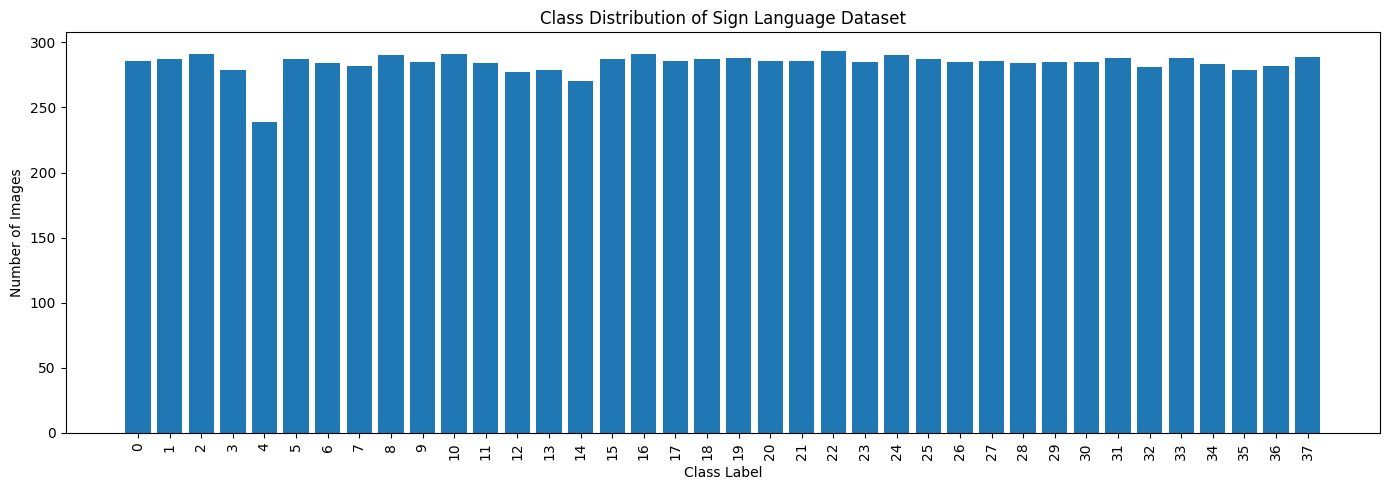

       train_images  test_images  total_images
count     38.000000         38.0     38.000000
mean     284.000000          0.0    284.000000
std        8.708492          0.0      8.708492
min      239.000000          0.0    239.000000
25%      283.250000          0.0    283.250000
50%      286.000000          0.0    286.000000
75%      287.750000          0.0    287.750000
max      293.000000          0.0    293.000000


In [9]:
# Class distribution chart
plt.figure(figsize=(14, 5))
plt.bar(data_summary["class"], data_summary["total_images"])
plt.title("Class Distribution of Sign Language Dataset")
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(data_summary.describe())

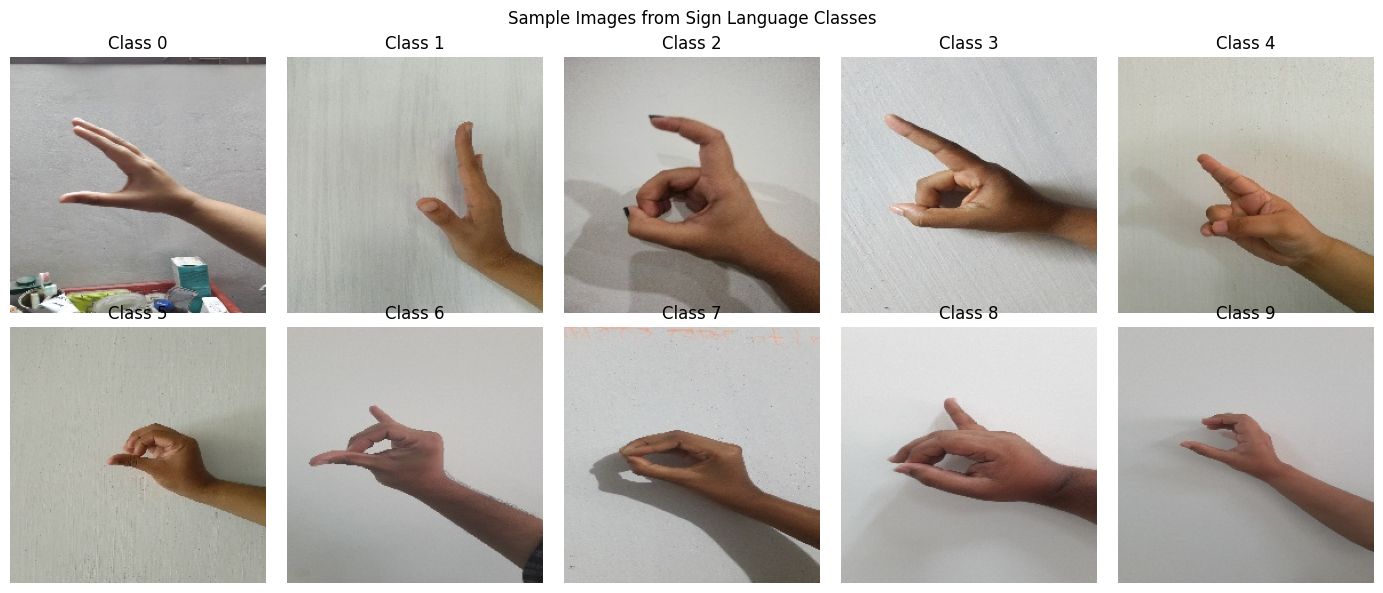

In [10]:
# Display sample images from first 10 classes
sample_classes = classes[:10]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i, class_name in enumerate(sample_classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(IMAGE_EXTENSIONS)]
    sample_image = random.choice(image_files)
    img_path = os.path.join(class_path, sample_image)

    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"Class {class_name}")
    axes[i].axis("off")

plt.suptitle("Sample Images from Sign Language Classes")
plt.tight_layout()
plt.show()

In [11]:
# Check image properties: size, mode, and format
first_class = classes[0]
first_class_path = os.path.join(TRAIN_DIR, first_class)
first_image_name = [f for f in os.listdir(first_class_path) if f.lower().endswith(IMAGE_EXTENSIONS)][0]
first_image_path = os.path.join(first_class_path, first_image_name)

sample_img = PILImage.open(first_image_path)

print("Sample image path:", first_image_path)
print("Image size:", sample_img.size)
print("Image mode:", sample_img.mode)
print("Image format:", sample_img.format)

Sample image path: /content/sign_language_dataset/Sign Language Detection/Train/0/20180627_232007.jpg
Image size: (224, 224)
Image mode: RGB
Image format: JPEG


---
# 🔧 Section 2: Data Preprocessing and Augmentation

The proposal/presentation states that the original image size is around **224×224**, and the project uses resizing, normalization, rotation, and zoom augmentation.

In this notebook, images are resized to **128×128** to reduce training time while preserving enough gesture information. If your instructor wants the same size as your friend's notebook, change only this line:

```python
IMG_SIZE = (224, 224)
```

Preprocessing and augmentation used:

- Resize images to 128×128
- Normalize pixels to 0–1
- Rotation augmentation
- Zoom augmentation
- Width and height shifting
- Shear transformation
- Train/validation split from the training folder

In [12]:
# Configuration constants
IMG_SIZE = (128, 128)      # Change to (224, 224) if required by instructor
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.15
EPOCHS_BASELINE = 25
EPOCHS_DEEPER = 25
EPOCHS_TRANSFER = 15

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    fill_mode="nearest"
)

# Validation generator without augmentation
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

# Test generator without augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = validation_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

print("Class mapping:")
print(class_indices)

Found 9194 images belonging to 38 classes.
Found 1598 images belonging to 38 classes.
Found 0 images belonging to 0 classes.
Class mapping:
{'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '4': 32, '5': 33, '6': 34, '7': 35, '8': 36, '9': 37}


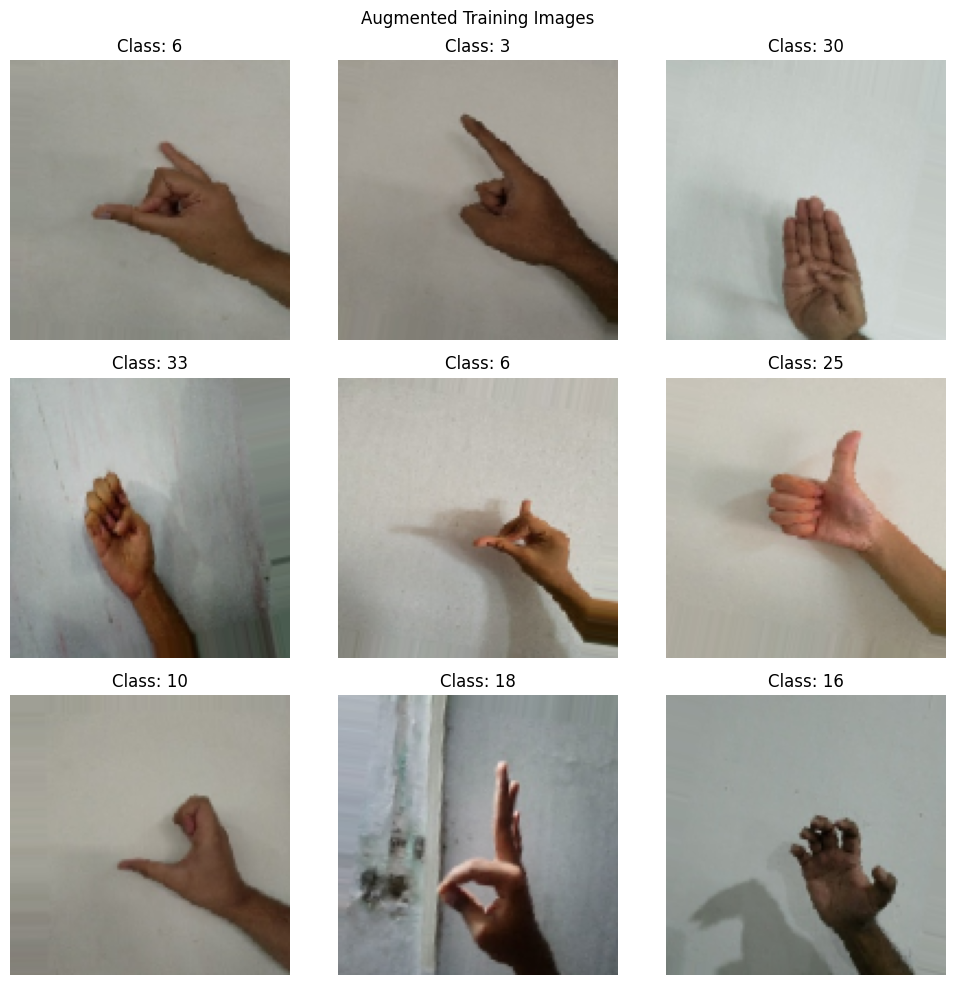

In [13]:
# Visualize augmented images
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    label_idx = np.argmax(labels[i])
    plt.title(f"Class: {idx_to_class[label_idx]}")
    plt.axis("off")

plt.suptitle("Augmented Training Images")
plt.tight_layout()
plt.show()

---
# 🛠️ Section 3: Helper Functions

These functions are used repeatedly for plotting training curves, evaluating models, and showing confusion matrices.

In [25]:
def plot_training_curves(history, title):
    """Plot training and validation accuracy/loss curves."""
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(cm, class_labels, title):
    """Plot confusion matrix using Matplotlib."""
    plt.figure(figsize=(14, 12))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels, rotation=90)
    plt.yticks(tick_marks, class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()


def evaluate_model(model, generator, model_name):
    """Evaluate model using accuracy, precision, recall, F1-score and confusion matrix."""
    generator.reset()
    y_prob = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes

    accuracy = np.mean(y_pred == y_true)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print('\n' + '='*60)
    print(f'{model_name} Evaluation Results')
    print('='*60)
    print(f'Accuracy : {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')

    print('\nClassification Report:')
    print(classification_report(
        y_true,
        y_pred,
        target_names=list(generator.class_indices.keys()),
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, list(generator.class_indices.keys()), f'{model_name} - Confusion Matrix')

    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, min_lr=1e-6)
]

---
# 🧠 Part A – Baseline CNN Model from Scratch

The baseline CNN follows the assignment requirement:

- 3 convolutional layers
- Pooling after each convolutional layer
- 3 fully connected layers
- Softmax output layer for 38-class classification

This model acts as the benchmark for comparison.

In [15]:
def build_baseline_cnn(num_classes, input_shape=(128, 128, 3)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation='relu'),


        Dense(128, activation='relu'),


        Dense(64, activation='relu'),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

baseline_model = build_baseline_cnn(
    num_classes=train_generator.num_classes,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,559,654 (25.02 MB)

 Trainable params: 6,559,654 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
print('Training Baseline CNN...')
start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_BASELINE,
    callbacks=callbacks
)

baseline_time = time.time() - start_time
print(f'Baseline CNN training time: {baseline_time:.2f} seconds')

Training Baseline CNN...
Epoch 1/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 62s 192ms/step - accuracy: 0.0467 - loss: 3.5834 - val_accuracy: 0.0932 - val_loss: 3.3876 - learning_rate: 0.0010
Epoch 2/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 166ms/step - accuracy: 0.1812 - loss: 2.9216 - val_accuracy: 0.2672 - val_loss: 2.5448 - learning_rate: 0.0010
Epoch 3/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 171ms/step - accuracy: 0.3866 - loss: 2.0366 - val_accuracy: 0.4268 - val_loss: 1.9408 - learning_rate: 0.0010
Epoch 4/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 166ms/step - accuracy: 0.5144 - loss: 1.5467 - val_accuracy: 0.4887 - val_loss: 1.7338 - learning_rate: 0.0010
Epoch 5/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 174ms/step - accuracy: 0.6053 - loss: 1.2774 - val_accuracy: 0.5770 - val_loss: 1.4414 - learning_rate: 0.0010
Epoch 6/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 165ms/step - accuracy: 0.6473 - loss: 1.1138 - val_accuracy: 0.5313 - val_loss: 1.6334 - learning_rate: 0.0010
Epoch 7/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 46s 1

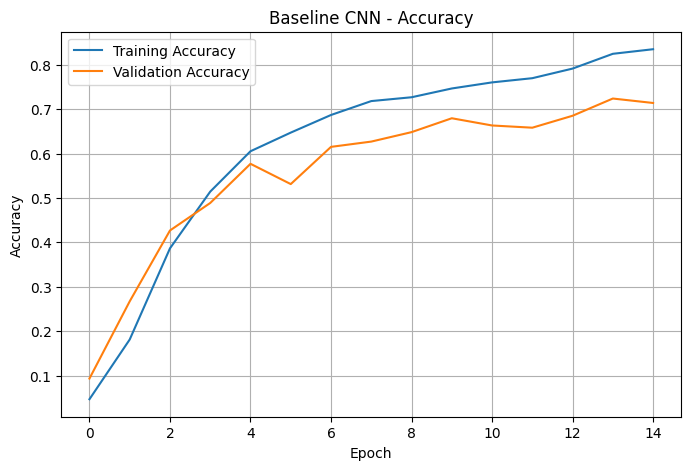

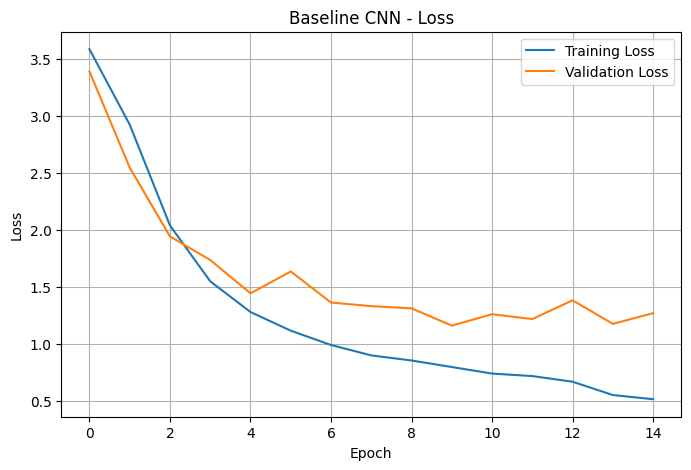

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step

Baseline CNN Evaluation Results
Accuracy : 0.6796
Precision: 0.7222
Recall   : 0.6796
F1-score : 0.6822

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        42
           1       0.82      0.84      0.83        43
          10       0.89      0.74      0.81        43
          11       0.76      0.81      0.78        42
          12       0.66      0.71      0.68        41
          13       0.59      0.39      0.47        41
          14       0.71      0.30      0.42        40
          15       0.67      0.67      0.67        43
          16       0.67      0.86      0.76        43
          17       0.68      0.81      0.74        42
          18       0.33      0.79      0.47        43
          19       0.82      0.33      0.47        43
           2       0.80      0.77      0.79        43
          20       0.84      0.76      0.80        42
          21       0

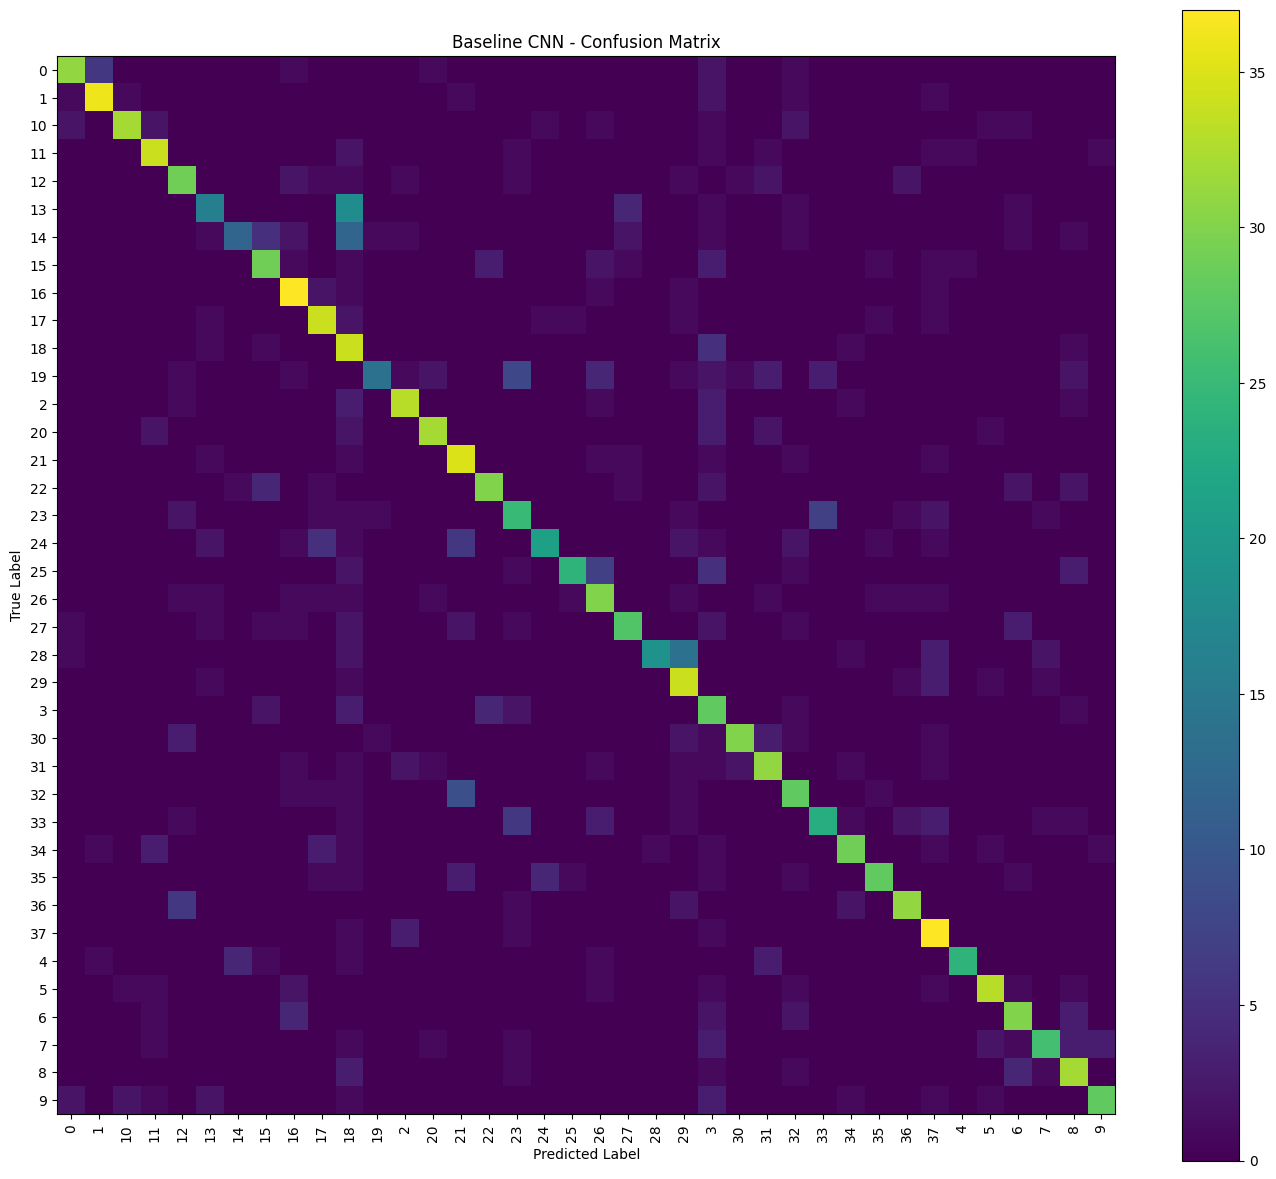

In [17]:
plot_training_curves(history_baseline, 'Baseline CNN')
baseline_results = evaluate_model(baseline_model, val_generator, 'Baseline CNN')

---
# 🧠 Part A – Deeper CNN with Regularization

The deeper CNN has at least double the convolutional layers compared to the baseline model. It also uses:

- Batch Normalization for stable training
- Dropout to reduce overfitting
- More convolutional filters for richer feature extraction

In [18]:
def build_deeper_cnn(num_classes, input_shape=(128, 128, 3), optimizer_name='adam'):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.40),

        Flatten(),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(num_classes, activation='softmax')
    ])

    if optimizer_name.lower() == 'adam':
        optimizer = Adam(learning_rate=0.001)
    elif optimizer_name.lower() == 'sgd':
        optimizer = SGD(learning_rate=0.01, momentum=0.9)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'sgd'")

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Deeper CNN with Adam
deeper_adam_model = build_deeper_cnn(
    num_classes=train_generator.num_classes,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    optimizer_name='adam'
)

deeper_adam_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 38)             │         4,90

 Total params: 8,716,998 (33.25 MB)

 Trainable params: 8,715,334 (33.25 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [26]:
import time
print('Training Deeper CNN with Adam...')
start_time = time.time()

history_deeper_adam = deeper_adam_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_DEEPER,
    callbacks=callbacks
)

deeper_adam_time = time.time() - start_time
print(f'Deeper CNN with Adam training time: {deeper_adam_time:.2f} seconds')

Training Deeper CNN with Adam...
Epoch 1/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.6025 - loss: 1.4645 - val_accuracy: 0.5263 - val_loss: 1.7370 - learning_rate: 2.7000e-05
Epoch 2/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 185ms/step - accuracy: 0.6212 - loss: 1.3993 - val_accuracy: 0.5613 - val_loss: 1.6333 - learning_rate: 2.7000e-05
Epoch 3/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 54s 189ms/step - accuracy: 0.6506 - loss: 1.3181 - val_accuracy: 0.5670 - val_loss: 1.5910 - learning_rate: 2.7000e-05
Epoch 4/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 55s 189ms/step - accuracy: 0.6614 - loss: 1.2627 - val_accuracy: 0.5826 - val_loss: 1.5445 - learning_rate: 2.7000e-05
Epoch 5/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 183ms/step - accuracy: 0.6772 - loss: 1.2144 - val_accuracy: 0.5776 - val_loss: 1.5632 - learning_rate: 2.7000e-05
Epoch 6/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 177ms/step - accuracy: 0.6923 - loss: 1.1516 - val_accuracy: 0.6101 - val_loss: 1.4889 - learning_rate: 2.7000e-05
Epoch 7/25
28

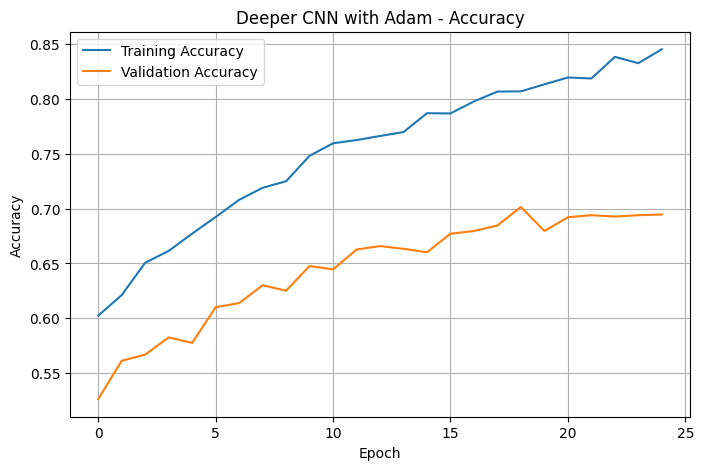

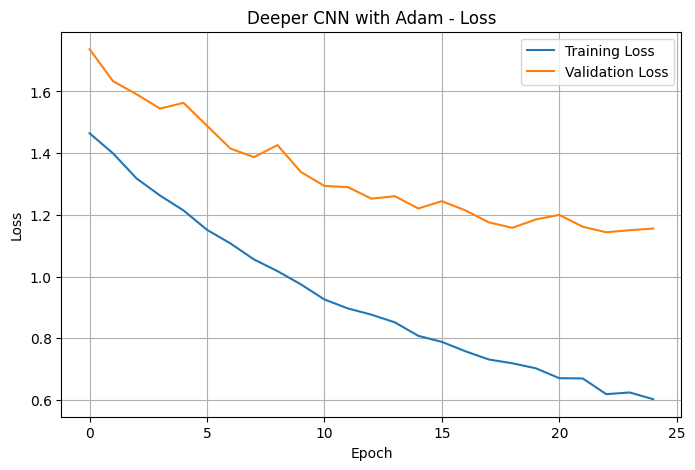

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step

Deeper CNN with Adam Evaluation Results
Accuracy : 0.6927
Precision: 0.7284
Recall   : 0.6927
F1-score : 0.6997

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.67      0.64        42
           1       0.82      0.63      0.71        43
          10       0.67      0.67      0.67        43
          11       0.80      0.76      0.78        42
          12       0.82      0.68      0.75        41
          13       0.62      0.73      0.67        41
          14       0.91      0.50      0.65        40
          15       0.84      0.63      0.72        43
          16       0.81      0.81      0.81        43
          17       0.85      0.83      0.84        42
          18       0.63      0.63      0.63        43
          19       0.55      0.51      0.53        43
           2       0.95      0.91      0.93        43
          20       0.80      0.76      0.78        42
          21

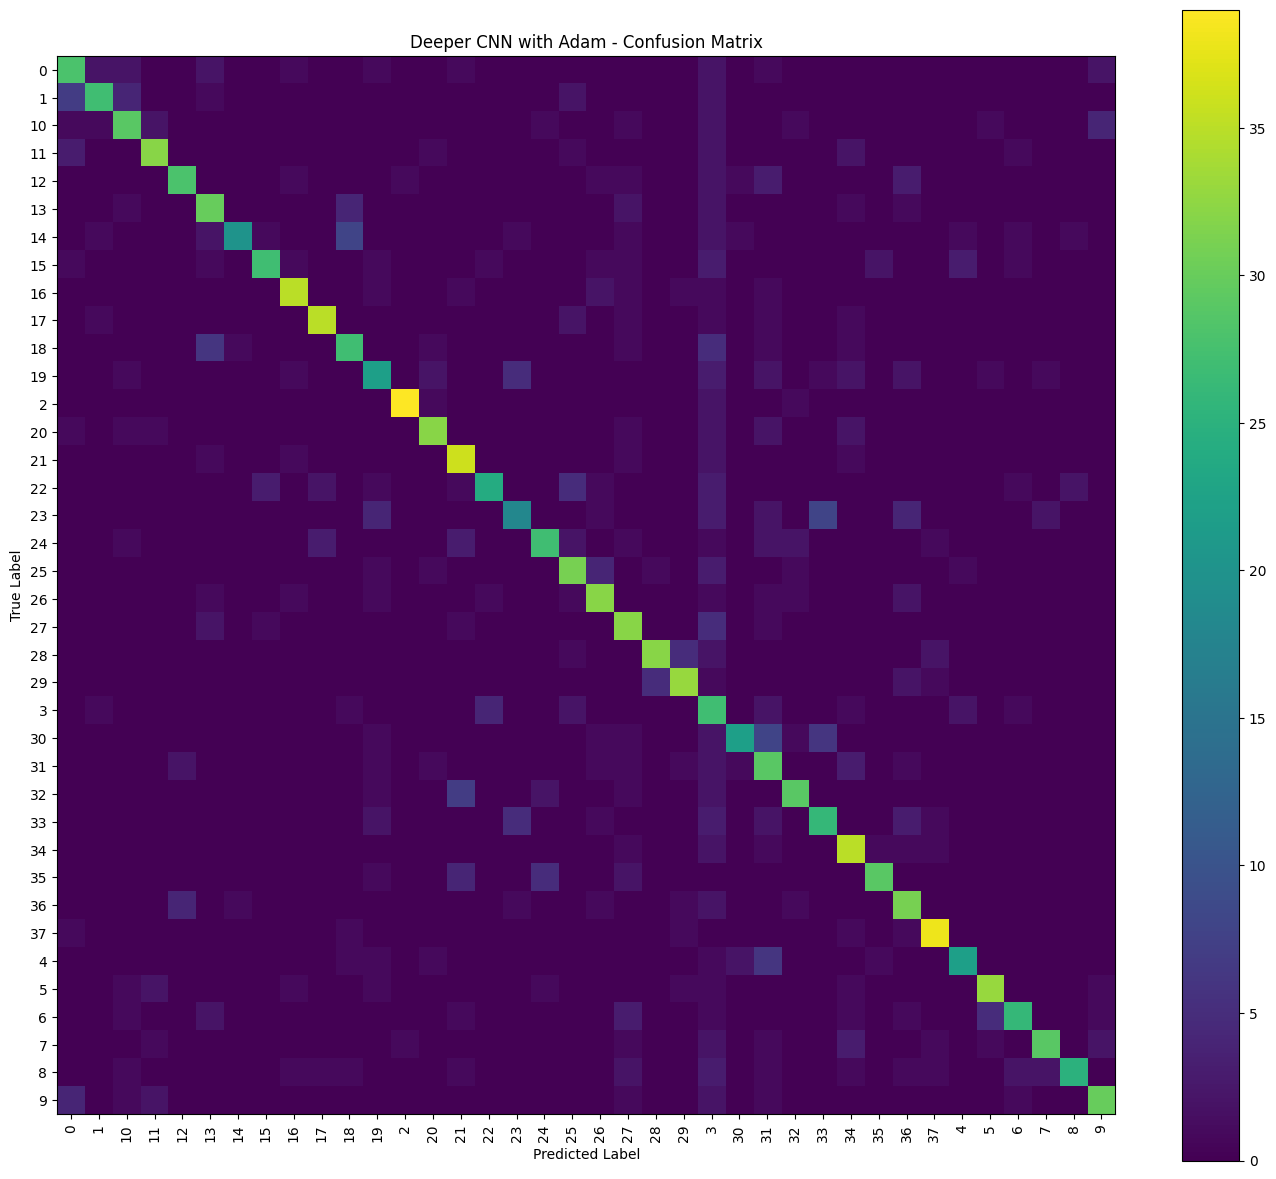

In [43]:
plot_training_curves(history_deeper_adam, 'Deeper CNN with Adam')
deeper_adam_results = evaluate_model(deeper_adam_model, val_generator, 'Deeper CNN with Adam')

---
# ⚖️ Optimizer Analysis: SGD vs Adam

This experiment trains the same deeper CNN architecture using SGD instead of Adam.

Expected comparison:

- Adam usually converges faster because it adapts learning rates automatically.
- SGD may train more slowly but can sometimes generalize well with enough epochs.

In [27]:
# Deeper CNN with SGD
deeper_sgd_model = build_deeper_cnn(
    num_classes=train_generator.num_classes,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    optimizer_name='sgd'
)

deeper_sgd_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 38)             │         4,90

 Total params: 8,716,998 (33.25 MB)

 Trainable params: 8,715,334 (33.25 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [29]:
print('Training Deeper CNN with SGD...')
start_time = time.time()

history_deeper_sgd = deeper_sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_DEEPER,
    callbacks=callbacks
)

deeper_sgd_time = time.time() - start_time
print(f'Deeper CNN with SGD training time: {deeper_sgd_time:.2f} seconds')

Training Deeper CNN with SGD...
Epoch 1/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 182ms/step - accuracy: 0.2427 - loss: 2.7497 - val_accuracy: 0.2272 - val_loss: 2.8861 - learning_rate: 1.0000e-03
Epoch 2/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.3078 - loss: 2.4818 - val_accuracy: 0.2741 - val_loss: 2.6699 - learning_rate: 1.0000e-03
Epoch 3/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 179ms/step - accuracy: 0.3711 - loss: 2.2318 - val_accuracy: 0.3511 - val_loss: 2.3423 - learning_rate: 1.0000e-03
Epoch 4/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 184ms/step - accuracy: 0.4146 - loss: 2.0750 - val_accuracy: 0.3899 - val_loss: 2.2231 - learning_rate: 1.0000e-04
Epoch 5/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 183ms/step - accuracy: 0.4338 - loss: 2.0122 - val_accuracy: 0.3955 - val_loss: 2.1945 - learning_rate: 1.0000e-04
Deeper CNN with SGD training time: 262.25 seconds


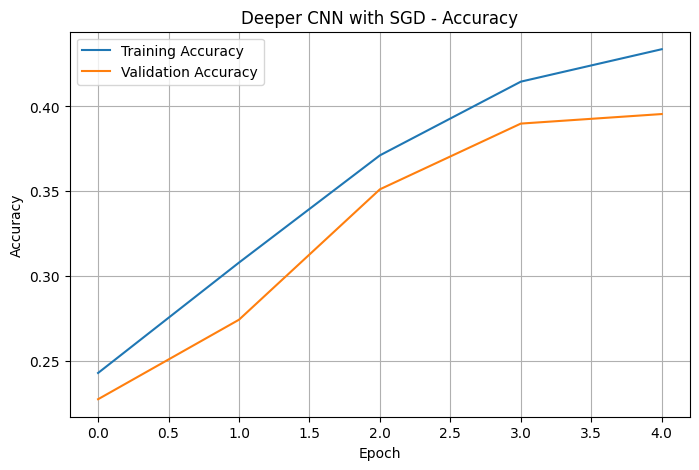

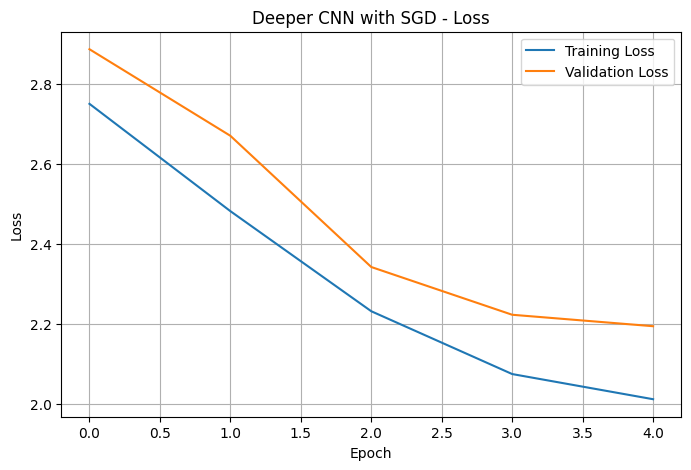

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step

Deeper CNN with SGD Evaluation Results
Accuracy : 0.2272
Precision: 0.3210
Recall   : 0.2272
F1-score : 0.1984

Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.10      0.11        42
           1       0.41      0.30      0.35        43
          10       0.00      0.00      0.00        43
          11       0.18      0.38      0.25        42
          12       0.27      0.15      0.19        41
          13       0.26      0.17      0.21        41
          14       0.10      0.03      0.04        40
          15       1.00      0.02      0.05        43
          16       0.25      0.35      0.29        43
          17       0.32      0.55      0.41        42
          18       0.12      0.19      0.14        43
          19       1.00      0.02      0.05        43
           2       0.25      0.02      0.04        43
          20       0.33      0.05      0.08        42
          21 

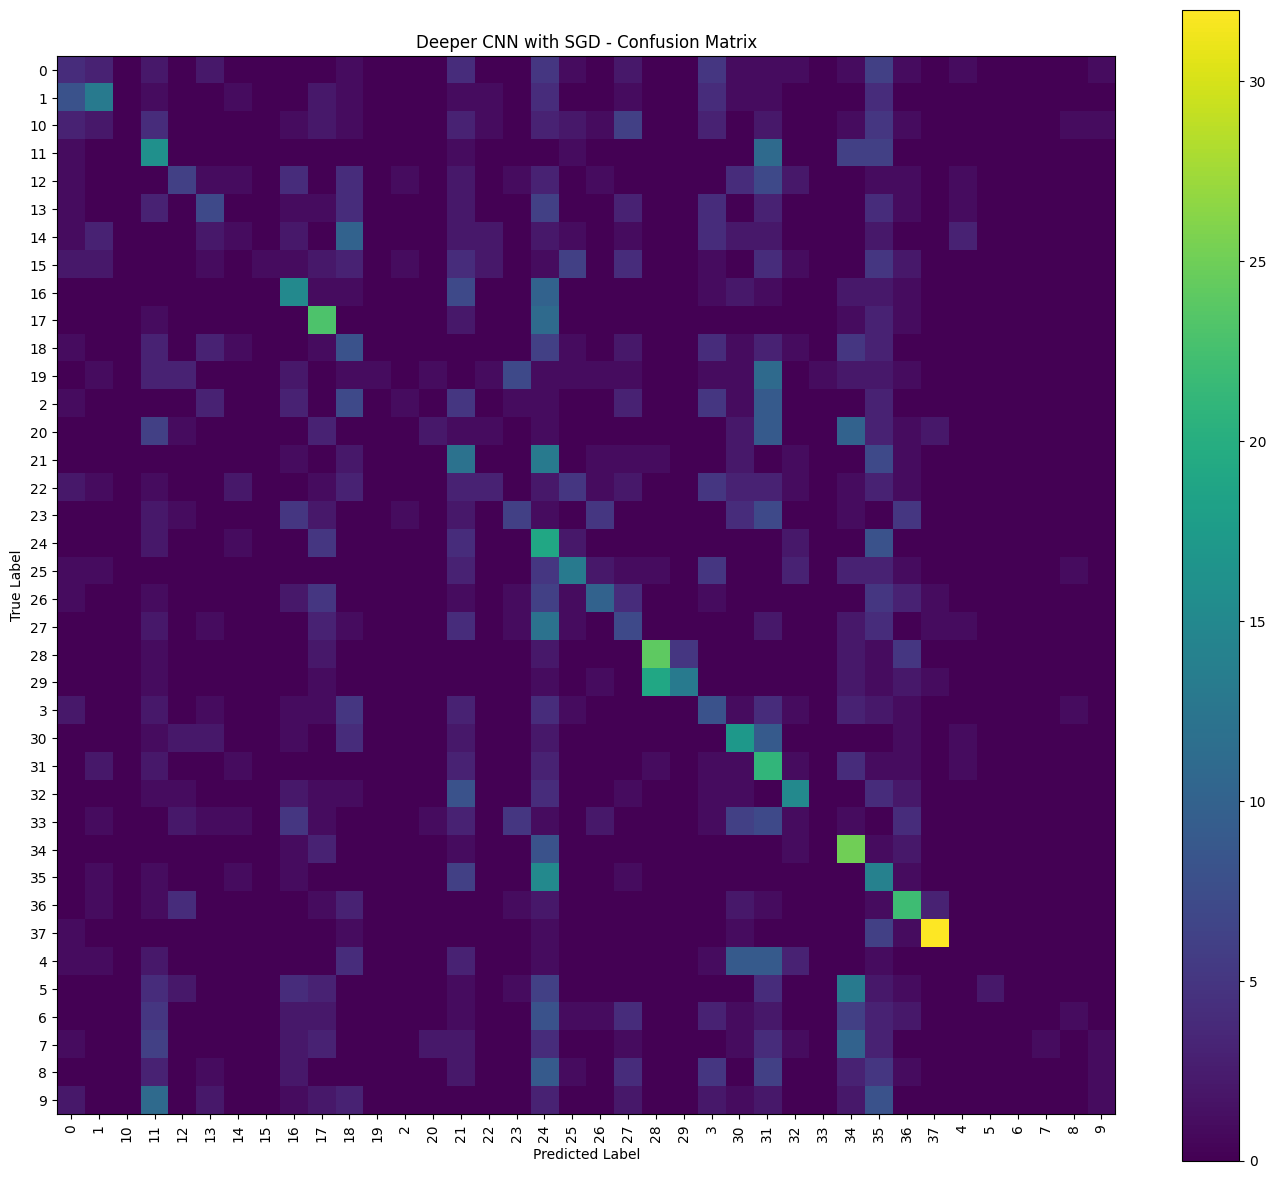

In [44]:
plot_training_curves(history_deeper_sgd, 'Deeper CNN with SGD')
deeper_sgd_results = evaluate_model(deeper_sgd_model, val_generator, 'Deeper CNN with SGD')

---
# 🧪 Ablation Study: Deeper CNN without Dropout

An ablation study removes one component from the model to understand its contribution.  
Here, Dropout is removed from the deeper CNN to observe whether overfitting increases.

In [30]:
def build_deeper_without_dropout(num_classes, input_shape=(128, 128, 3)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation='relu'),
        BatchNormalization(),

        Dense(128, activation='relu'),
        BatchNormalization(),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

ablation_model = build_deeper_without_dropout(
    num_classes=train_generator.num_classes,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

ablation_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 38)             │         4,90

 Total params: 8,716,998 (33.25 MB)

 Trainable params: 8,715,334 (33.25 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [31]:
print('Training Ablation Model without Dropout...')
start_time = time.time()

history_ablation = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_DEEPER,
    callbacks=callbacks
)

ablation_time = time.time() - start_time
print(f'Ablation model training time: {ablation_time:.2f} seconds')

Training Ablation Model without Dropout...
Epoch 1/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 69s 210ms/step - accuracy: 0.1684 - loss: 3.2334 - val_accuracy: 0.0576 - val_loss: 6.1236 - learning_rate: 0.0010
Epoch 2/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.4507 - loss: 1.9161 - val_accuracy: 0.1677 - val_loss: 3.6066 - learning_rate: 0.0010
Epoch 3/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 54s 187ms/step - accuracy: 0.5981 - loss: 1.3697 - val_accuracy: 0.3492 - val_loss: 2.7353 - learning_rate: 0.0010
Epoch 4/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 54s 186ms/step - accuracy: 0.7232 - loss: 0.9456 - val_accuracy: 0.6821 - val_loss: 1.1400 - learning_rate: 1.0000e-04
Epoch 5/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 184ms/step - accuracy: 0.7567 - loss: 0.8481 - val_accuracy: 0.6977 - val_loss: 1.1273 - learning_rate: 1.0000e-04
Epoch 6/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 81s 181ms/step - accuracy: 0.7759 - loss: 0.7713 - val_accuracy: 0.7165 - val_loss: 1.1320 - learning_rate: 1.0000e-04
Epoch 7/25
288/

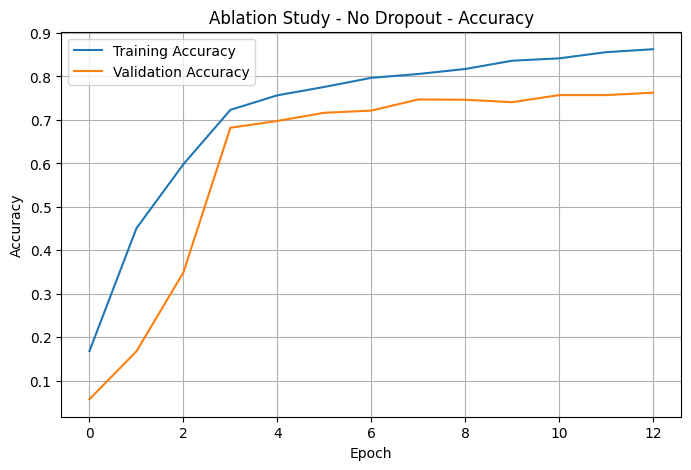

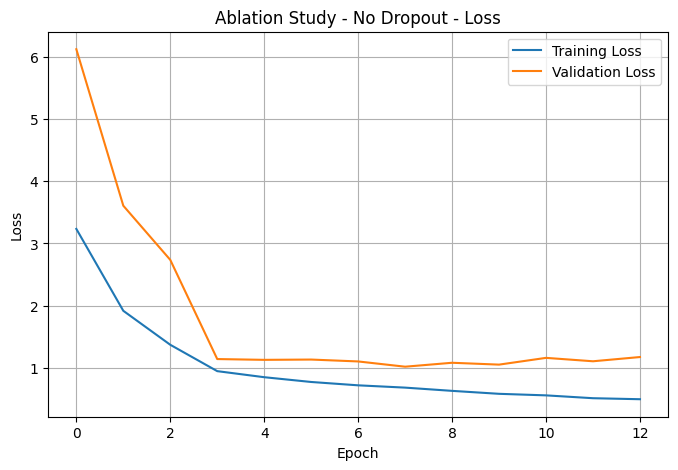

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step

Ablation Study - No Dropout Evaluation Results
Accuracy : 0.7472
Precision: 0.7709
Recall   : 0.7472
F1-score : 0.7522

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.79      0.70        42
           1       0.85      0.65      0.74        43
          10       0.84      0.74      0.79        43
          11       0.79      0.79      0.79        42
          12       0.78      0.76      0.77        41
          13       0.86      0.73      0.79        41
          14       0.69      0.62      0.66        40
          15       0.84      0.60      0.70        43
          16       0.88      0.86      0.87        43
          17       0.81      0.81      0.81        42
          18       0.58      0.81      0.68        43
          19       0.69      0.63      0.66        43
           2       0.79      0.86      0.82        43
          20       0.87      0.81      0.84        42
     

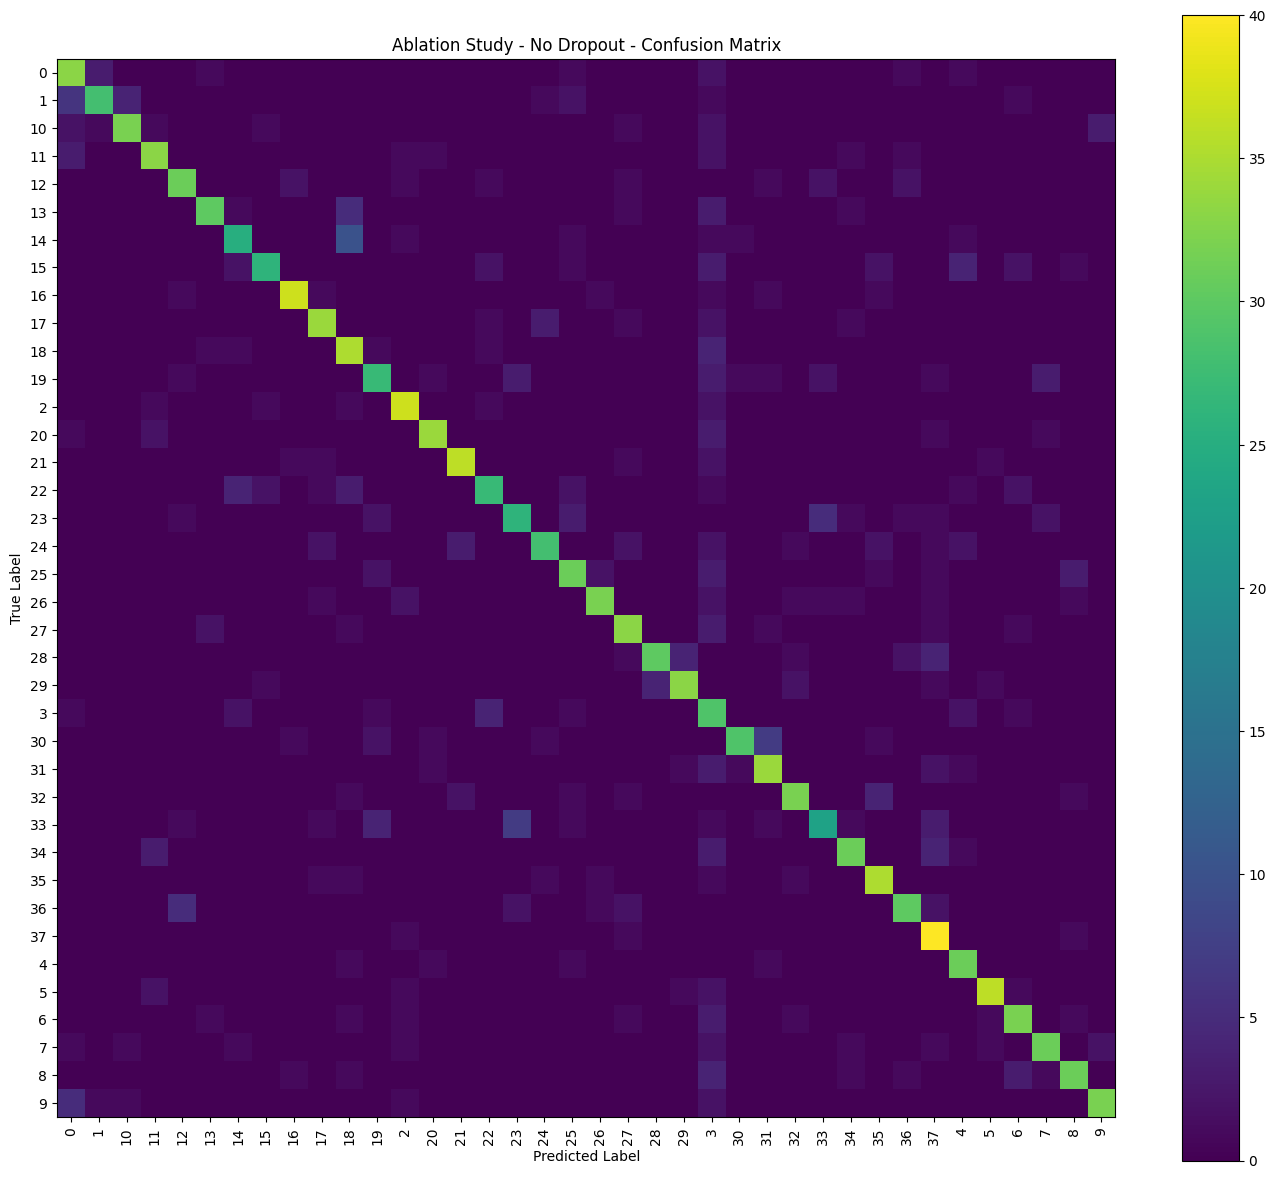

In [33]:
plot_training_curves(history_ablation, 'Ablation Study - No Dropout')
ablation_results = evaluate_model(ablation_model, val_generator, 'Ablation Study - No Dropout')

---
# 🤖 Part B – Transfer Learning with MobileNetV2

Transfer learning uses a model already trained on a large dataset such as ImageNet.  
Here, MobileNetV2 is used because it is lightweight and suitable for Google Colab.

Two phases are used:

1. **Feature extraction:** Freeze MobileNetV2 and train only the new classifier layers.
2. **Fine-tuning:** Unfreeze the last layers and train with a very small learning rate.

In [34]:
# Generators for MobileNetV2 use preprocess_input instead of simple rescale
transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VALIDATION_SPLIT,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    fill_mode='nearest'
)

transfer_validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VALIDATION_SPLIT
)

transfer_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

transfer_train_generator = transfer_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

transfer_val_generator = transfer_validation_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

transfer_test_generator = transfer_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 9194 images belonging to 38 classes.
Found 1598 images belonging to 38 classes.
Found 0 images belonging to 0 classes.


In [35]:
def build_mobilenetv2_model(num_classes, input_shape=(128, 128, 3)):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze base model for feature extraction
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model

transfer_model, mobilenet_base = build_mobilenetv2_model(
    num_classes=transfer_train_generator.num_classes,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,623,718 (10.01 MB)

 Trainable params: 365,734 (1.40 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [36]:
print('Phase 1: Feature Extraction — Training classifier layers only...')
start_time = time.time()

history_transfer_phase1 = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=EPOCHS_TRANSFER,
    callbacks=callbacks
)

transfer_phase1_time = time.time() - start_time
print(f'Transfer learning phase 1 training time: {transfer_phase1_time:.2f} seconds')

Phase 1: Feature Extraction — Training classifier layers only...
Epoch 1/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 108s 301ms/step - accuracy: 0.1668 - loss: 3.0477 - val_accuracy: 0.4393 - val_loss: 2.0208 - learning_rate: 5.0000e-04
Epoch 2/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 171ms/step - accuracy: 0.3859 - loss: 2.0142 - val_accuracy: 0.5713 - val_loss: 1.4842 - learning_rate: 5.0000e-04
Epoch 3/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 172ms/step - accuracy: 0.4924 - loss: 1.6103 - val_accuracy: 0.6458 - val_loss: 1.2232 - learning_rate: 5.0000e-04
Epoch 4/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 165ms/step - accuracy: 0.5526 - loss: 1.3944 - val_accuracy: 0.6527 - val_loss: 1.1758 - learning_rate: 5.0000e-05
Epoch 5/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - accuracy: 0.5647 - loss: 1.3473 - val_accuracy: 0.6552 - val_loss: 1.1501 - learning_rate: 5.0000e-05
Transfer learning phase 1 training time: 303.42 seconds


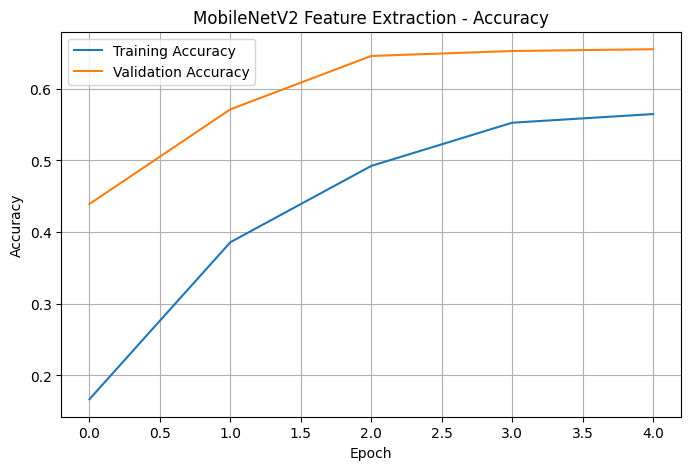

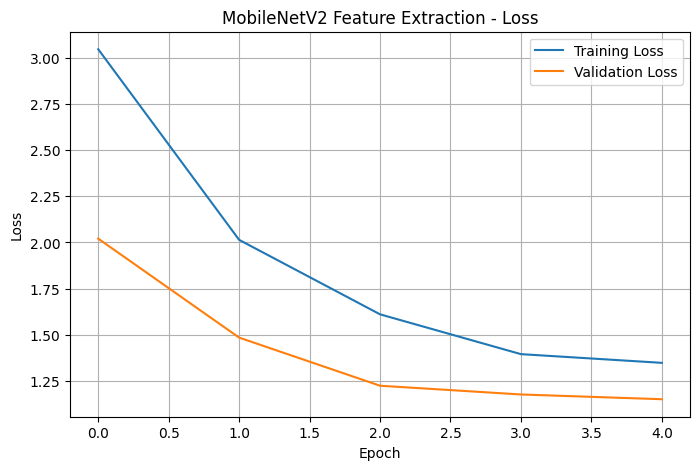

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 151ms/step

MobileNetV2 Feature Extraction Evaluation Results
Accuracy : 0.4393
Precision: 0.4735
Recall   : 0.4393
F1-score : 0.4120

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.33      0.44        42
           1       0.38      0.84      0.53        43
          10       0.70      0.49      0.58        43
          11       0.64      0.83      0.72        42
          12       0.20      0.05      0.08        41
          13       0.16      0.44      0.24        41
          14       0.60      0.07      0.13        40
          15       0.25      0.02      0.04        43
          16       0.82      0.53      0.65        43
          17       0.60      0.62      0.61        42
          18       0.40      0.09      0.15        43
          19       0.55      0.51      0.53        43
           2       0.38      0.07      0.12        43
          20       0.71      0.83      0.77        42


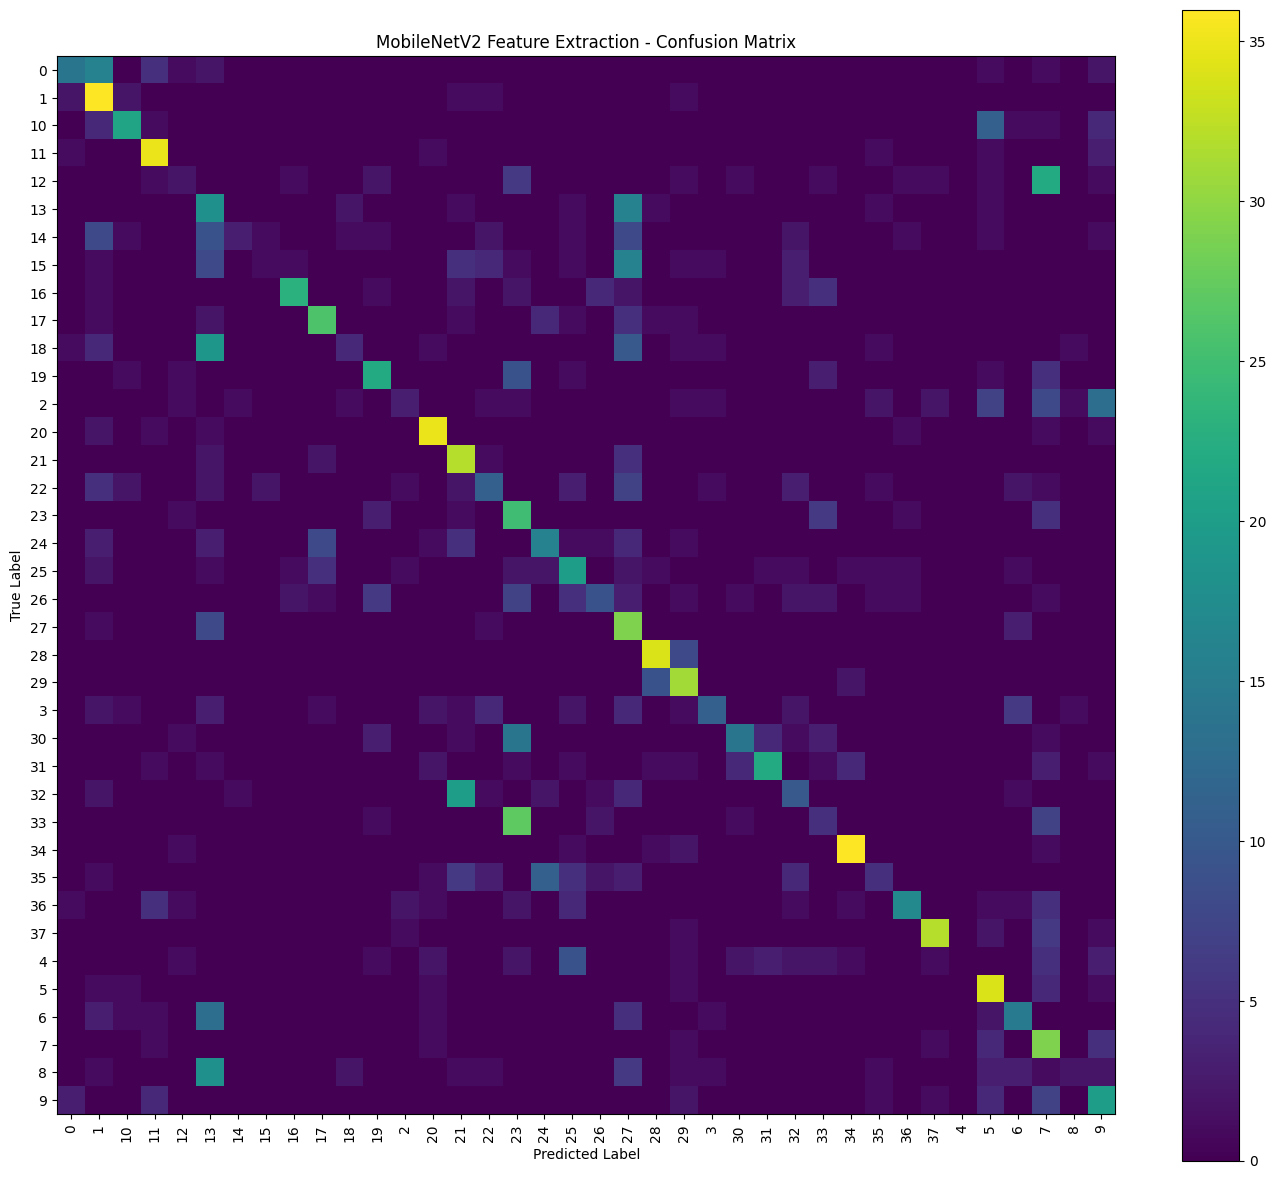

In [38]:
plot_training_curves(history_transfer_phase1, 'MobileNetV2 Feature Extraction')
transfer_phase1_results = evaluate_model(transfer_model, transfer_val_generator, 'MobileNetV2 Feature Extraction')

## 🔓 Fine-Tuning MobileNetV2

In fine-tuning, the last 30 layers of the MobileNetV2 base model are unfrozen.  
A very small learning rate is used to avoid destroying the useful pre-trained features.

In [39]:
# Fine-tune only the last 30 layers
mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2: Fine-tuning last 30 MobileNetV2 layers...')
start_time = time.time()

history_transfer_phase2 = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=10,
    callbacks=callbacks
)

transfer_phase2_time = time.time() - start_time
print(f'Transfer learning phase 2 training time: {transfer_phase2_time:.2f} seconds')

Phase 2: Fine-tuning last 30 MobileNetV2 layers...
Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 89s 242ms/step - accuracy: 0.2459 - loss: 2.6314 - val_accuracy: 0.4806 - val_loss: 1.7925 - learning_rate: 1.0000e-05
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 171ms/step - accuracy: 0.3167 - loss: 2.3359 - val_accuracy: 0.5150 - val_loss: 1.6412 - learning_rate: 1.0000e-05
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 183ms/step - accuracy: 0.3669 - loss: 2.1246 - val_accuracy: 0.5469 - val_loss: 1.5320 - learning_rate: 1.0000e-05
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 174ms/step - accuracy: 0.3797 - loss: 2.0664 - val_accuracy: 0.5532 - val_loss: 1.5433 - learning_rate: 1.0000e-06
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 174ms/step - accuracy: 0.3819 - loss: 2.0330 - val_accuracy: 0.5563 - val_loss: 1.5574 - learning_rate: 1.0000e-06
Transfer learning phase 2 training time: 292.02 seconds


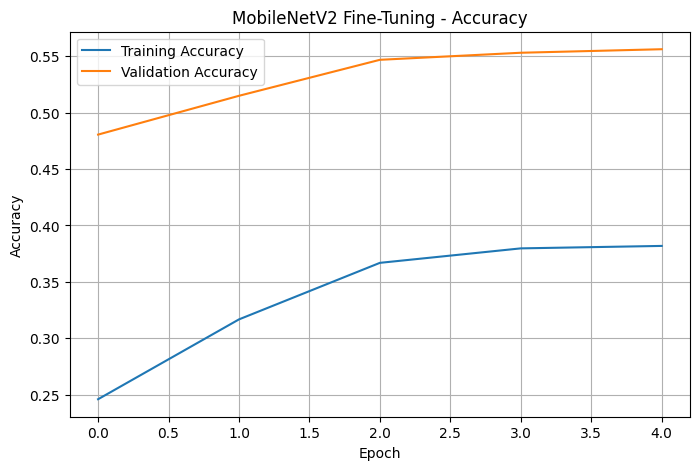

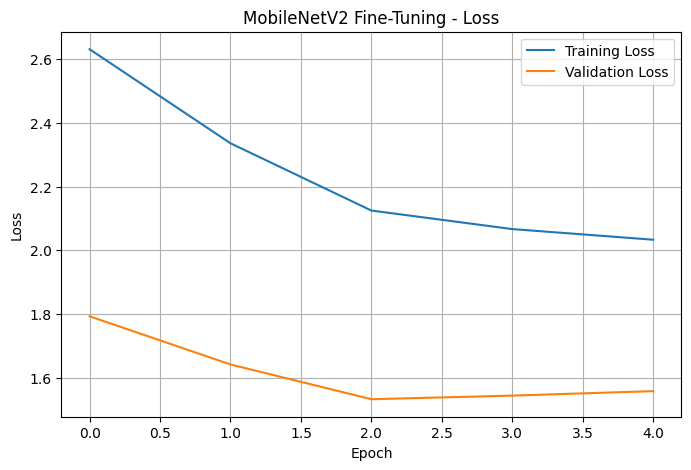

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step

MobileNetV2 Fine-Tuned Evaluation Results
Accuracy : 0.4806
Precision: 0.5168
Recall   : 0.4806
F1-score : 0.4501

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.60      0.57        42
           1       0.41      0.86      0.55        43
          10       0.72      0.60      0.66        43
          11       0.48      0.88      0.62        42
          12       0.44      0.10      0.16        41
          13       0.32      0.54      0.40        41
          14       0.40      0.10      0.16        40
          15       0.50      0.05      0.09        43
          16       1.00      0.47      0.63        43
          17       0.50      0.79      0.61        42
          18       0.54      0.16      0.25        43
          19       0.67      0.51      0.58        43
           2       0.20      0.02      0.04        43
          20       0.56      0.83      0.67        42
        

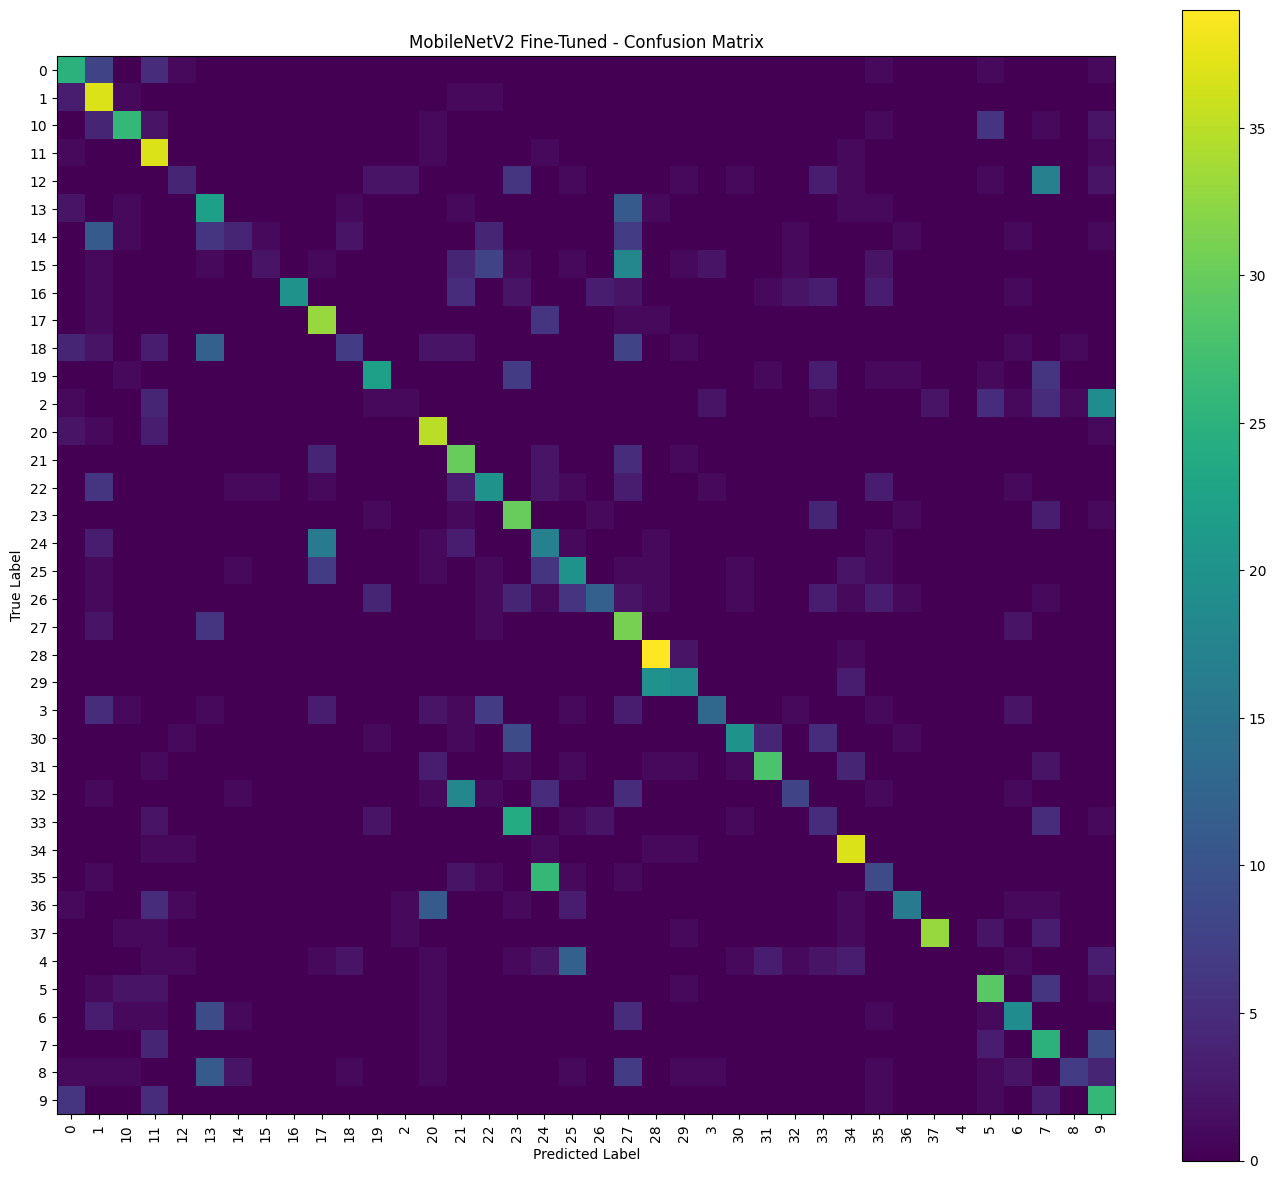

In [47]:
plot_training_curves(history_transfer_phase2, 'MobileNetV2 Fine-Tuning')
transfer_finetuned_results = evaluate_model(transfer_model, transfer_val_generator, 'MobileNetV2 Fine-Tuned')

---
# 📊 Final Model Comparison

This table compares all models using accuracy, precision, recall, F1-score, and training time.

In [48]:
results = [
    baseline_results,
    deeper_adam_results,
    deeper_sgd_results,
    ablation_results,
    transfer_phase1_results,
    transfer_finetuned_results
]

results_df = pd.DataFrame(results)

training_times = {
    'Baseline CNN': baseline_time,
    'Deeper CNN with Adam': deeper_adam_time,
    'Deeper CNN with SGD': deeper_sgd_time,
    'Ablation Study - No Dropout': ablation_time,
    'MobileNetV2 Feature Extraction': transfer_phase1_time,
    'MobileNetV2 Fine-Tuned': transfer_phase1_time + transfer_phase2_time
}

results_df['training_time_seconds'] = results_df['model'].map(training_times)
results_df = results_df.sort_values(by='accuracy', ascending=False)
results_df

,model,accuracy,precision,recall,f1_score,training_time_seconds
3,Ablation Study - No Dropout,0.747184,0.770906,0.747184,0.752203,729.129458
1,Deeper CNN with Adam,0.692741,0.728386,0.692741,0.699728,1319.186922
0,Baseline CNN,0.679599,0.722204,0.679599,0.682240,739.158848
5,MobileNetV2 Fine-Tuned,0.480601,0.516780,0.480601,0.450061,595.436560
4,MobileNetV2 Feature Extraction,0.439299,0.473531,0.439299,0.411991,303.420558
2,Deeper CNN with SGD,0.227159,0.320992,0.227159,0.198397,262.253770


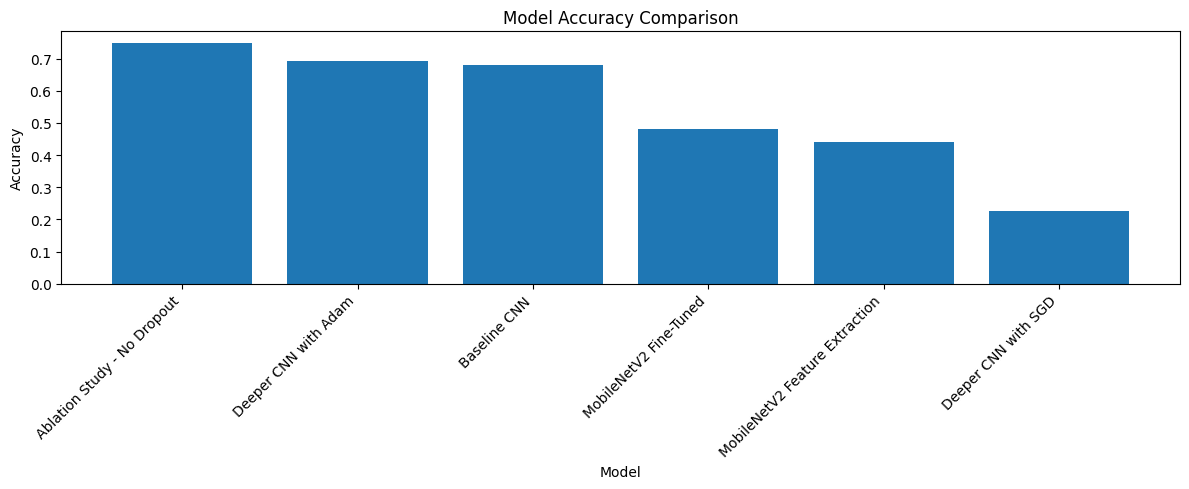

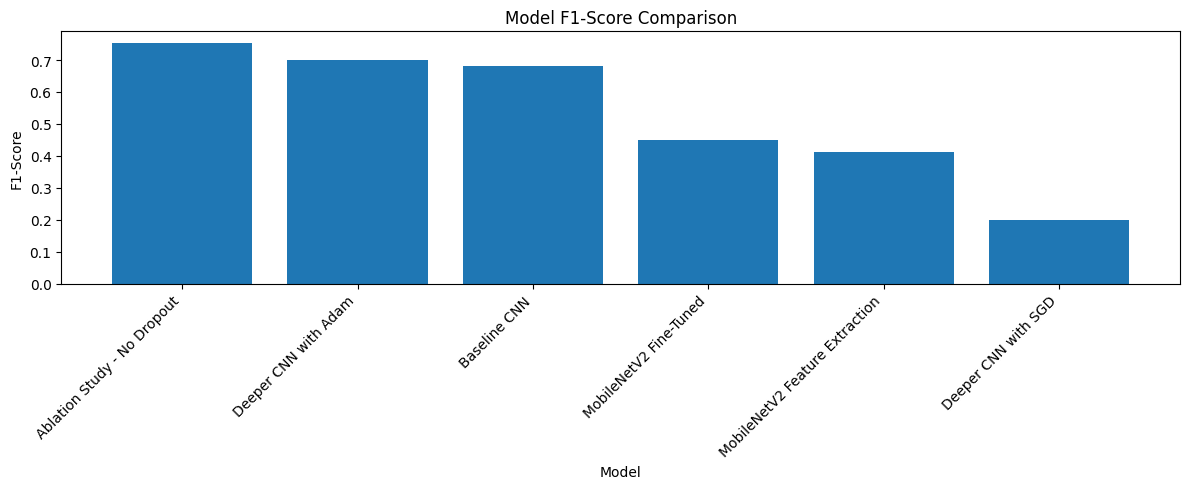

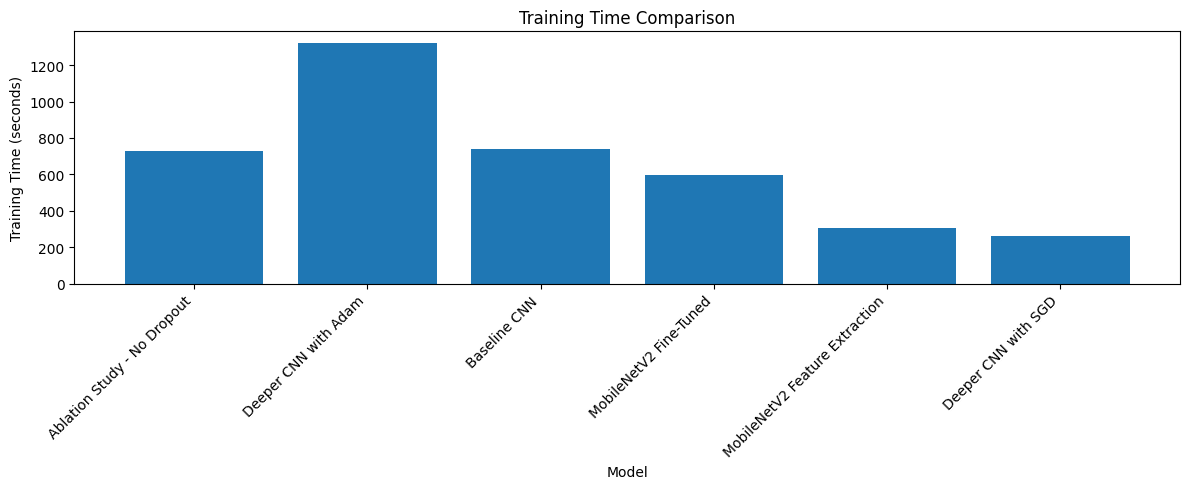

In [49]:
plt.figure(figsize=(12, 5))
plt.bar(results_df['model'], results_df['accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df['model'], results_df['f1_score'])
plt.title('Model F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df['model'], results_df['training_time_seconds'])
plt.title('Training Time Comparison')
plt.xlabel('Model')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
# 🔮 Sample Predictions

This section displays a few test images with actual and predicted labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


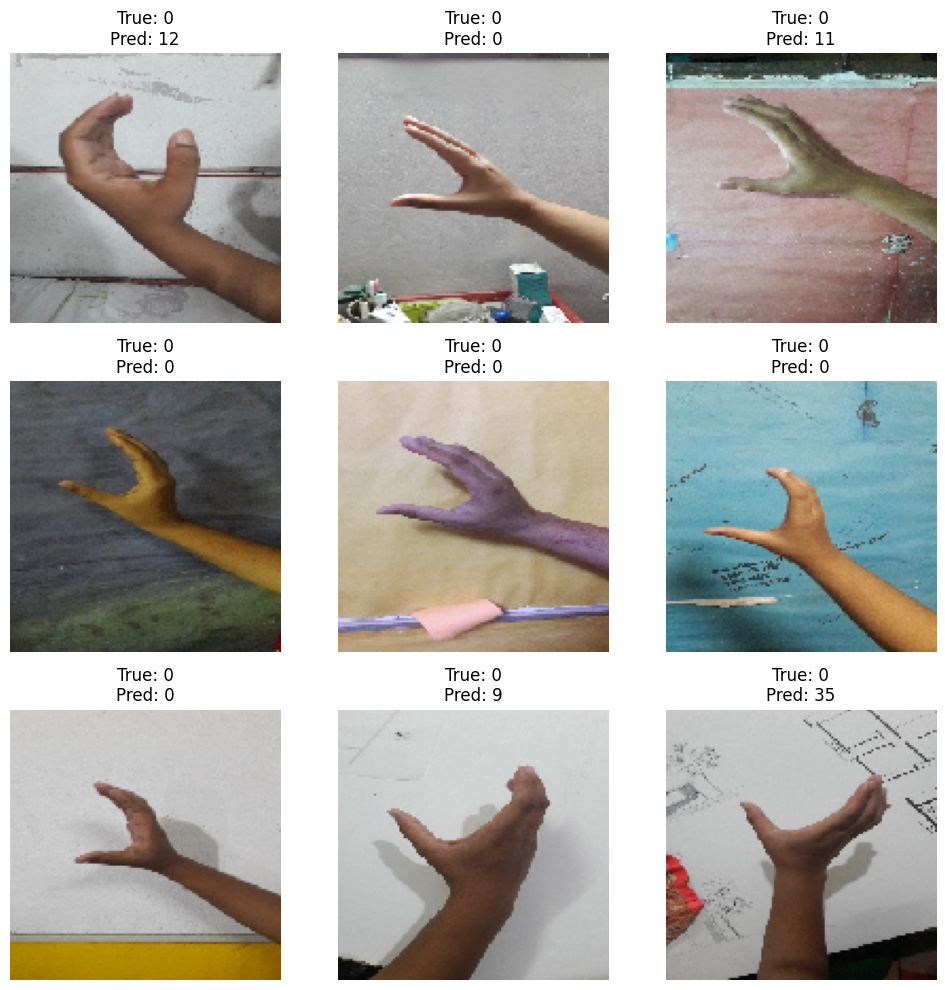

In [53]:
def show_sample_predictions(model, generator, num_images=9, transfer_model_used=False):
    generator.reset()
    images, labels = next(generator)
    predictions = model.predict(images)

    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(min(num_images, len(images))):
        plt.subplot(3, 3, i + 1)

        display_img = images[i]
        # MobileNetV2 preprocess_input changes image range to [-1, 1]
        if display_img.min() < 0:
            display_img = (display_img + 1) / 2

        plt.imshow(display_img)
        plt.title(
            f"""True: {idx_to_class[true_classes[i]]}\nPred: {idx_to_class[predicted_classes[i]]}"""
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Showing predictions using the fine-tuned transfer model
show_sample_predictions(transfer_model, transfer_val_generator, transfer_model_used=True)


---
# 💾 Save Trained Models

This saves the trained models to Google Drive so they are not lost when Colab disconnects.

In [54]:
SAVE_DIR = '/content/drive/MyDrive/6CS012_sign_language_models/'
os.makedirs(SAVE_DIR, exist_ok=True)

baseline_model.save(os.path.join(SAVE_DIR, 'baseline_cnn.h5'))
deeper_adam_model.save(os.path.join(SAVE_DIR, 'deeper_cnn_adam.h5'))
deeper_sgd_model.save(os.path.join(SAVE_DIR, 'deeper_cnn_sgd.h5'))
ablation_model.save(os.path.join(SAVE_DIR, 'ablation_no_dropout.h5'))
transfer_model.save(os.path.join(SAVE_DIR, 'mobilenetv2_finetuned.h5'))

print('All models saved to:', SAVE_DIR)

All models saved to: /content/drive/MyDrive/6CS012_sign_language_models/


---
# 📝 Summary of Findings

Write this section after running the notebook and seeing your actual results.

## Key Findings Template

**1. Baseline CNN:**  
The baseline CNN provided a simple benchmark using three convolutional layers and three dense layers. It was useful for understanding whether a basic CNN can learn sign language gestures from scratch.

**2. Deeper CNN:**  
The deeper CNN used more convolutional layers, Batch Normalization, and Dropout. If validation accuracy improved, it shows that the deeper architecture learned stronger gesture features. If performance did not improve, it may indicate overfitting or insufficient data.

**3. SGD vs Adam:**  
Adam usually converged faster because it adapts the learning rate automatically. SGD may require more epochs but can sometimes generalize well.

**4. Ablation Study:**  
Removing Dropout helps test whether Dropout reduces overfitting. If training accuracy increased but validation accuracy decreased, it means Dropout was important for generalization.

**5. Transfer Learning:**  
MobileNetV2 used pre-trained ImageNet features. If it outperformed CNNs from scratch, it shows that transfer learning is effective for this dataset.

**6. Challenges:**  
The main challenges were similar-looking gestures, lighting variation, hand orientation differences, background noise, and minor class imbalance.